# Molecules

The design note used to say molecules were out of scope "by construction".

That was wrong, and checking it took one line. A `Molecule` has a composition,
so `X` and `var` build for water exactly as they do for a crystal — H:2, O:1.
The only thing that failed was a decoder that assumed a lattice.

So molecules live on the same axes as everything else: `obs` is one row per
species, `X` is still the composition matrix, the sites axis is still one row
per atom, and `obs['is_periodic']` tells the two apart. **One object can hold
both**, which is what a study of a catalyst and its adsorbates, an electrolyte
and its salt, or a MOF and its guest actually needs.

What genuinely differs is the analysis: a point group rather than a space
group, covalent bonds rather than a coordination polyhedron, fragments rather
than defects.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 213   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Four molecules with textbook symmetry, so every answer below can be checked
against what a chemistry course would tell you.

In [2]:
from pymatgen.core import Molecule

water = Molecule(["O", "H", "H"],
                 [[0, 0, 0], [0.76, 0.59, 0], [-0.76, 0.59, 0]])
methane = Molecule(["C", "H", "H", "H", "H"],
                   [[0, 0, 0], [0.63, 0.63, 0.63], [-0.63, -0.63, 0.63],
                    [-0.63, 0.63, -0.63], [0.63, -0.63, -0.63]])
ammonia = Molecule(["N", "H", "H", "H"],
                   [[0, 0, 0.12], [0, 0.94, -0.27],
                    [0.81, -0.47, -0.27], [-0.81, -0.47, -0.27]])
ethanol = Molecule(
    ["C", "C", "O", "H", "H", "H", "H", "H", "H"],
    [[-1.2, 0.2, 0], [0.0, -0.6, 0], [1.1, 0.3, 0],
     [-1.2, 0.9, 0.9], [-1.2, 0.9, -0.9], [-2.1, -0.4, 0],
     [0.0, -1.2, 0.9], [0.0, -1.2, -0.9], [1.9, -0.2, 0]])

md = mv.mol.from_molecules([water, methane, ammonia, ethanol])
md

AnnData object with n_obs × n_vars = 4 × 4
    obs: 'is_periodic'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is'
    obsm: 'structures'
    layers: None (.X)

In [3]:
pd.DataFrame(md.X.toarray(), index=["H2O", "CH4", "NH3", "EtOH"],
             columns=md.var_names)

element,H,C,N,O
H2O,2.0,0.0,0.0,1.0
CH4,4.0,1.0,0.0,0.0
NH3,3.0,0.0,1.0,0.0
EtOH,6.0,2.0,0.0,1.0


The composition matrix, built without being asked, exactly as for a crystal.
Nothing about `X` cares whether a formula unit repeats.

In [4]:
mv.pp.describe(md)
md.obs[["formula", "nsites", "molecular_weight", "volume", "density",
        "is_periodic"]].round(3)

,formula,nsites,molecular_weight,volume,density,is_periodic
0,H2O,3,18.015,NaN,NaN,False
1,H4C,5,16.042,NaN,NaN,False
2,H3N,4,17.031,NaN,NaN,False
3,H6C2O,9,46.068,NaN,NaN,False


`volume` and `density` are NaN, because they are properties of a *cell* and a
molecule has none. They become NaN rather than absent so a dataset mixing
crystals with molecules stays one table:

In [5]:
mixed = mv.data.from_structures(
    [water, mv.structures(mv.datasets.metals(["Cu"]))[0]])
mv.pp.describe(mixed)

mixed.obs[["formula", "nsites", "molecular_weight", "volume", "is_periodic"]]

,formula,nsites,molecular_weight,volume,is_periodic
0,H2O,3,18.01528,NaN,False
1,Cu,4,254.18400,47.237713,True


## Symmetry

A molecule has a point group where a crystal has a space group.

In [6]:
mv.mol.point_group(md)

md.obs[["formula", "point_group", "symmetry_order", "is_chiral",
        "can_be_polar"]]

,formula,point_group,symmetry_order,is_chiral,can_be_polar
0,H2O,C2v,4.0,False,True
1,H4C,Td,24.0,False,False
2,H3N,C3v,6.0,False,True
3,H6C2O,Cs,2.0,False,True


C2v for water, **Td** for methane, C3v for ammonia, Cs for ethanol — the
textbook answers, with the group orders to match (4, 24, 6, 2).

Two consequences come free, and the methane row is the interesting one.

**Methane cannot carry a dipole.** Not "does not" — *cannot*. Td contains
operations that map any candidate dipole vector onto its own negative, so the
only vector consistent with the symmetry is zero. A dipole survives only in C1,
Cs, Cn and Cnv; everywhere else it is forbidden. That is a hard selection rule,
and it is why methane has no permanent dipole while water and ammonia do.

**Chirality** is the other one: a molecule is chiral exactly when its point
group contains no improper operation. All four here have a mirror plane, so
none has an enantiomer.

Text(0.5, 1.0, 'blue can be polar; grey is forbidden by symmetry')

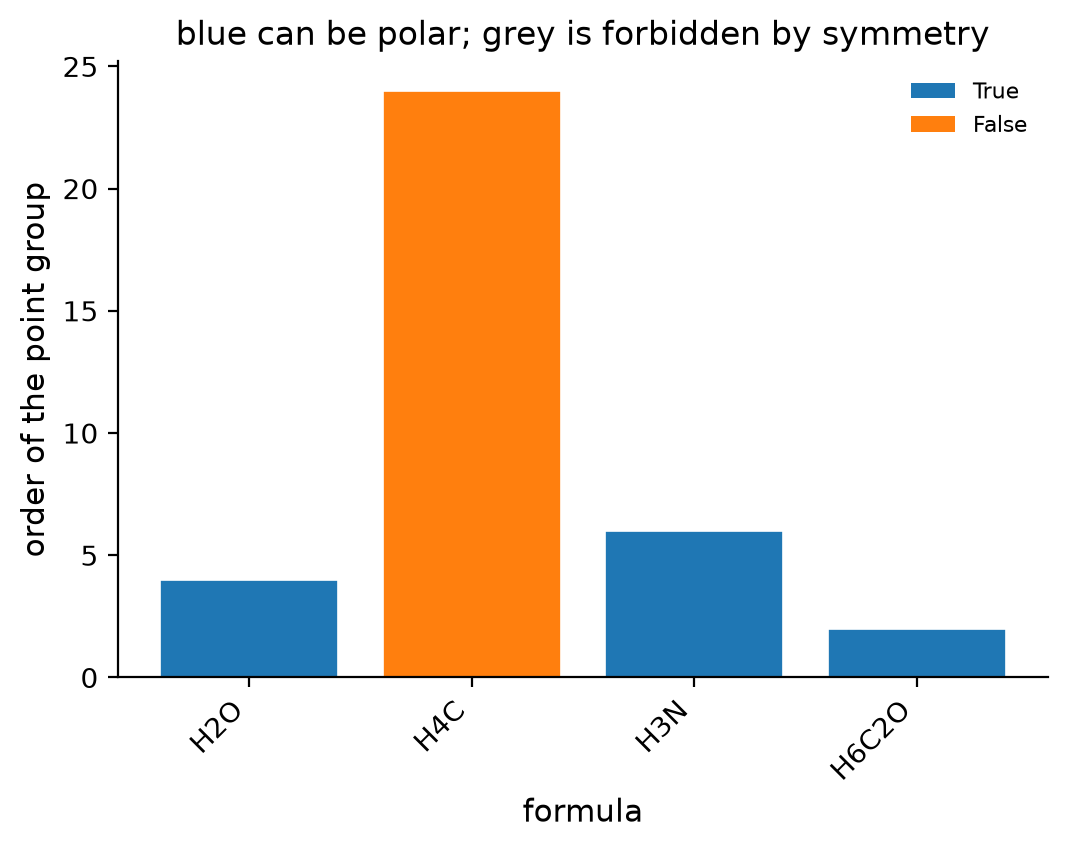

In [7]:
ax = mv.pl.scatter(md, "formula", "symmetry_order", kind="bar",
                   color="can_be_polar")
ax.set_ylabel("order of the point group")
ax.set_title("blue can be polar; grey is forbidden by symmetry")

## Bonds

The molecular counterpart of `mv.env.bonds`, landing in the **same slot** —
`obsp` on the sites object — so a graph algorithm does not need to know which
kind of material it was handed.

In [8]:
sites = mv.multi.sites(md)
mv.mol.bonds(md, sites)

sites.obsp["bonds"].shape, sites.obsp["bonds"].nnz, sites.uns["bonds"]["kind"]

((21, 21), 34, 'covalent')

Different *perception*, though. A crystal's neighbours come from Voronoi solid
angles; a molecule's bonds come from covalent radii, because a molecule has no
periodic environment to take a solid angle over.

In [9]:
mv.mol.BOND_STRATEGIES

{'covalent': 'CovalentBondNN — bonded when the separation is within a tolerance of the sum of covalent radii; needs no extra dependency and is the default',
 'openbabel': "OpenBabelNN — Open Babel's perception, which knows about bond orders; needs the openbabel Python bindings",
 'critic2': 'Critic2NN — from a charge density, so it is the only one that is not a distance heuristic; needs the critic2 program'}

## Descriptors that need the graph

In [10]:
mv.mol.descriptors(md)

md.obs[["formula", "heavy_atoms", "n_bonds", "n_rings", "rotatable_bonds",
        "radius_of_gyration"]].round(3)

,formula,heavy_atoms,n_bonds,n_rings,rotatable_bonds,radius_of_gyration
0,H2O,1.0,2.0,0.0,0.0,0.680
1,H4C,1.0,4.0,0.0,0.0,0.976
2,H3N,1.0,3.0,0.0,0.0,0.829
3,H6C2O,3.0,8.0,0.0,2.0,1.527


Ethanol has **two rotatable bonds** — C–C and C–O. The C–H bonds are terminal
and do not count, because rotating about one moves nothing but hydrogens.

That number is what decides how many conformers a search has to cover, and it
grows the cost of everything downstream exponentially.

```{note}
`n_rings` is the cyclomatic number — `edges - nodes + components` — which counts
independent cycles rather than the chemist's smallest set of smallest rings.
They agree for ordinary molecules and differ for fused polycyclics.
```

## Fragments

Break every acyclic bond in turn and keep the pieces. This is what a
bond-dissociation study or a degradation-pathway search enumerates.

In [11]:
one = mv.mol.from_molecules([ethanol])
mv.pp.describe(one)

fragments = mv.mol.fragments(one)
mv.pp.describe(fragments)

fragments.obs[["broken_bond", "fragment_index", "fragment_formula",
               "fragment_size"]].head(10)

,broken_bond,fragment_index,fragment_formula,fragment_size
0,C0-C1,0,H3C1,4
1,C0-C1,0,H3C1O1,5
2,C0-H3,1,H5C2O1,8
3,C0-H3,1,H1,1
4,C0-H4,2,H5C2O1,8
5,C0-H4,2,H1,1
6,C0-H5,3,H5C2O1,8
7,C0-H5,3,H1,1
8,C1-O2,4,H5C2,7
9,C1-O2,4,H1O1,2


In [12]:
fragments.obs.groupby("fragment_index")["fragment_size"].sum().to_dict()

{0: 9, 1: 9, 2: 9, 3: 9, 4: 9, 5: 9, 6: 9, 7: 9}

Every cut splits nine atoms into pieces that still total nine — mass is
conserved, which is the cheapest possible check that the graph surgery is
right.

Breaking C0–C1 gives CH₃ and CH₃O, which is the C–C scission an ethanol
combustion mechanism starts with.

```{warning}
Note `fragment_formula` next to `formula`. pymatgen's **reduced** formula
applies the diatomic convention, so a single hydrogen atom reads `H2` and a
hydroxyl reads `H2O2`. That is right for a stoichiometry and actively
misleading for a fragment, which is a specific set of atoms — so the unreduced
formula is recorded alongside.
```

In [13]:
fragments.obs[fragments.obs["fragment_size"] == 1][
    ["broken_bond", "fragment_formula", "formula"]].head(3)

,broken_bond,fragment_formula,formula
3,C0-H3,H1,H2
5,C0-H4,H1,H2
7,C0-H5,H1,H2


Ring bonds are not cut, because one cut cannot separate a ring — the molecule
stays connected. A ring needs two, and `fragments` says so rather than
returning nothing without explanation.

Compute the fragments and the parent at the same level and the difference is a
bond dissociation energy. matverse does not take that step for you, because
which reference state you subtract is a choice.

## Deduplication

The molecular counterpart of `mv.pp.dedup`, and it exists for the same reason:
a database query returns the same species many times, and relaxing each costs
the same as relaxing something new.

In [14]:
moved = Molecule(["O", "H", "H"], np.asarray(water.cart_coords) + 5.0)
library = mv.mol.from_molecules([water, moved, ethanol, methane])
mv.pp.describe(library)
mv.mol.match(library)

library.obs[["formula", "molecule_group", "is_duplicate"]]

,formula,molecule_group,is_duplicate
0,H2O,0,False
1,H2O,0,True
2,H6C2O,2,False
3,H4C,3,False


In [15]:
library.uns["molecule_match"]

{'tolerance': 0.1,
 'source': 'input',
 'n_unique': 3,
 'n_duplicates': 1,
 'method': 'geometry',
 'matcher': 'Kabsch superposition with Hungarian atom assignment',
 'note': 'two molecules match when the best rigid-body superposition over all atom assignments leaves an RMSD within tolerance, in angstrom'}

The translated copy of water is recognised: matching is on the reduced formula
and the heavy-atom distance spectrum, which is invariant to rotation,
translation and relabelling.

## Looking at them

`mv.pl.structure` draws either kind — a molecule or a crystal — and picks an
interactive viewer when one is installed.

Text(0.5, 1.0, 'ethanol, projected along its thinnest axis')

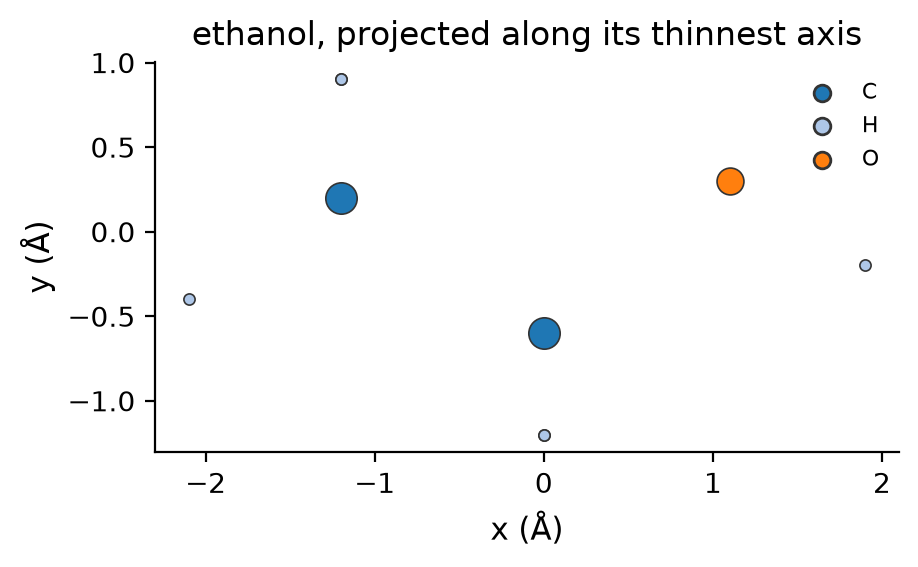

In [16]:
ax = mv.pl.structure(one, 0, backend="matplotlib")
ax.set_title("ethanol, projected along its thinnest axis")

Crude, and it needs nothing extra. With `py3Dmol` installed the default backend
is an interactive viewer instead; neither replaces VESTA or Crystal Toolkit for
real inspection, and that is not what they are for. This is the quick look you
take twenty times a day to catch a slab built upside down or a molecule that
came out of a parser inside out.

## What still applies

Almost everything, because the substrate did not change.

In [17]:
mv.pp.qc(md)
mv.feat.element_stats(md)
mv.calc.energy(md, level="emt")

md.obs[["formula", "is_valid", "energy_per_atom_emt"]].round(4)

/scratch/users/steorra/analysis/omicverse_dev/matverse/matverse/feat.py:106: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(masked, axis=1)
/scratch/users/steorra/analysis/omicverse_dev/matverse/matverse/feat.py:108: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(masked, axis=1)
/scratch/users/steorra/analysis/omicverse_dev/matverse/matverse/feat.py:110: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(masked, axis=1) - np.nanmin(masked, axis=1)


,formula,is_valid,energy_per_atom_emt
0,H2O,True,0.9016
1,H4C,True,0.3958
2,H3N,True,0.8473
3,H6C2O,True,0.4586


QC, composition descriptors and even a calculator run unmodified. EMT is
parameterised for C, N, O and H, so those numbers mean something — not much,
but something.

## What refuses, and why

A periodic operation on a molecule would have to invent a lattice, so it
refuses instead:

In [18]:
try:
    mv.mol.point_group(mv.datasets.metals(["Cu"]))
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: mv.mol.point_group needs molecules and every row of this dataset is periodic. Build one with mv.data.from_molecules, or check obs['is_periodic'] after mv.pp.describe.


```{seealso}
[Environments and bands](structure_and_bands.ipynb) is the crystalline half of
the same bonding question. [Coming from pymatgen](from_pymatgen.ipynb) lists
what matverse still does not do.
```

## Are the bonds the right length?

`mv.pp.qc` catches atoms sitting on top of one another. It cannot catch the
subtler failure a generated molecule makes: bonds that exist and are the wrong
length. A 1.9 Å C–C bond is not a strained conformer — it is not a molecule —
and no minimum-distance check will say so, because 1.9 Å is a perfectly
ordinary distance between two atoms that are *not* bonded.

In [19]:
import numpy as np

exact_water = Molecule(["O", "H", "H"],
                       [[0, 0, 0], [0.96, 0, 0], [-0.24, 0.93, 0]])
stretched = Molecule([site.specie for site in ethanol],
                     np.asarray(ethanol.cart_coords) * 1.25)

check = mv.mol.from_molecules([exact_water, ethanol, stretched])
mv.pp.describe(check)
mv.mol.bond_lengths(check)

check.obs[["formula", "n_bonds_measured", "mean_bond_deviation",
           "max_bond_deviation", "n_unusual_bonds", "bond_lengths_ok"]].round(3)

,formula,n_bonds_measured,mean_bond_deviation,max_bond_deviation,n_unusual_bonds,bond_lengths_ok
0,H2O,2.0,0.000,0.000,0.0,True
1,H6C2O,8.0,0.031,0.098,0.0,True
2,H6C2O,1.0,0.263,0.263,1.0,False


Water comes out at **zero** deviation, because it was built at exactly the
tabulated 0.96 Å O–H. Ethanol is within a few hundredths.

The stretched copy is the row to read, and **`n_bonds_measured` is the column
that matters** — not the deviation. Bonds are found by covalent radius, so a 25%
stretch does not produce long bonds; it produces almost *no* bonds. Eight become
one. A deviation computed from the single survivor is nearly meaningless, and
the count is the loud signal.

```{note}
Lengths are compared against the **single-bond** value throughout, so a double
or triple bond reads as short by design: C=C at 1.34 Å against a tabulated 1.54
is a deviation of 0.2. Read `n_unusual_bonds` as "worth looking at" rather than
"wrong".
```

## Two questions that both mean "the same molecule"

`mv.mol.match` groups molecules by superposing them — Kabsch for the rotation,
Hungarian for the atom labels. That answers "is this the same *shape*".

A **conformer** is the case where the two questions come apart. Rotate ethanol's
hydroxyl hydrogen about the C–O bond: every bond length is preserved and the
geometry moves.

In [20]:
conformer = ethanol.copy()
conformer.rotate_sites(
    indices=[8], theta=1.2,
    axis=np.array(ethanol[2].coords) - np.array(ethanol[1].coords),
    anchor=ethanol[2].coords)

pair = mv.mol.from_molecules([ethanol, conformer])
mv.pp.describe(pair)

for how in ("geometry", "topology"):
    mv.mol.match(pair, method=how)
    print(how, "->", pair.uns["molecule_match"]["n_unique"], "unique")

geometry -> 2 unique
topology -> 1 unique


**Geometry says two molecules. Topology says one.**

Neither is wrong. `method='geometry'` superposes and measures RMSD — this
conformer sits 0.29 Å away, outside the default tolerance of 0.1.
`method='topology'` compares the bond graph and ignores shape entirely.

Which you want depends on whether conformers are the thing you are
deduplicating or the thing you are studying. That is why it is a `dispatch`
rather than a default: the registry entry names both routes, so an agent
choosing between them can see that the choice exists.

## Which bond breaks first

The bond dissociation energy is the energy of the pieces minus the energy of the
whole. It decides which bond in a battery electrolyte oxidises first and which
C–H a combustion mechanism abstracts, and `mv.mol.fragments` has already done
the breaking — what is left is arithmetic on two energies:

In [21]:
from pymatgen.core import Molecule

alcohol = Molecule(
    ["C", "C", "O", "H", "H", "H", "H", "H", "H"],
    [[-1.1, 0.2, 0.0], [0.2, -0.5, 0.0], [1.3, 0.4, 0.0], [-1.0, 1.3, 0.0],
     [-1.7, -0.1, 0.9], [-1.7, -0.1, -0.9], [0.3, -1.2, 0.9],
     [0.3, -1.2, -0.9], [2.1, -0.1, 0.0]])

whole = mv.mol.from_molecules([alcohol])
whole.obs_names = ["ethanol"]
pieces = mv.mol.fragments(whole, depth=1)

# stand-in energies: a real screen would put a calculator here
whole.obs["energy_x"] = [-100.0]
pieces.obs["energy_x"] = [-10.0 * n for n in pieces.obs["fragment_size"]]

bde = mv.mol.dissociation(pieces, whole, level="x")
bde.obs[["broken_bond", "bond_dissociation_energy_x", "n_fragments"]]

,broken_bond,bond_dissociation_energy_x,n_fragments
0,C0-C1,10.0,2
1,C0-H3,10.0,2
2,C0-H4,10.0,2
3,C0-H5,10.0,2
4,C1-O2,10.0,2
5,C1-H6,10.0,2
6,C1-H7,10.0,2
7,O2-H8,10.0,2


Eight bonds, one row each, every one named. With the placeholder energies above
they all come out equal, which is the point of choosing them that way — every
cut of ethanol leaves nine atoms between the fragments, so at a fixed energy per
atom the arithmetic has to give the same answer eight times. Put a real
calculator in and the spread appears.

```{warning}
**The fragments are radicals**, and that is where the accuracy goes. A radical
has an unpaired electron, and a method that is fine for closed-shell molecules
can be badly wrong for one — universal potentials especially, since they are
trained mostly on closed-shell equilibrium structures. Read the *ordering* of
bonds within a molecule as the useful output; treat the absolute numbers as
indicative unless the level was chosen for open shells.

Geometries are used as they are, so this is the **vertical** dissociation
energy. Relax the fragments first for the adiabatic one; the two differing is
the fragment relaxation energy, which is information rather than a problem.
```

## What is actually on the molecule

A formula does not say what a molecule does. C₂H₆O is ethanol or dimethyl
ether depending on where the oxygen sits, and those behave nothing alike. A
screen over candidate molecules almost always wants *"the ones with a
carboxylic acid"* rather than *"the ones with two carbons"*.

`mv.mol.functional_groups` walks out from the heteroatoms and reports what it
finds:

In [22]:
from pymatgen.core import Molecule

ethanol = Molecule(
    ["C", "C", "O", "H", "H", "H", "H", "H", "H"],
    [[-1.1, 0.2, 0.0], [0.2, -0.5, 0.0], [1.3, 0.4, 0.0], [-1.0, 1.3, 0.0],
     [-1.7, -0.1, 0.9], [-1.7, -0.1, -0.9], [0.3, -1.2, 0.9],
     [0.3, -1.2, -0.9], [2.1, -0.1, 0.0]])
water = Molecule(["O", "H", "H"],
                 [[0, 0, 0.117], [0, 0.757, -0.469], [0, -0.757, -0.469]])

groups = mv.mol.from_molecules([ethanol, water])
groups.obs_names = ["ethanol", "water"]

try:
    mv.mol.functional_groups(groups)
    result = groups.obs[["functional_groups", "n_functional_groups"]]
except ImportError as exc:
    result = str(exc)[:200]      # openbabel is an optional extra
result

"every molecule failed in openbabel. Its Python bindings need libXrender at runtime and fail without it — `conda install -c conda-forge xorg-libxrender`, or your distribution's libxrender1. First error"

Ethanol comes back as `[CH3];[OH]` — a methyl and a hydroxyl, which is what it
is. The column is a sorted, semicolon-separated **string** on purpose, so it
can go straight into `mv.screen.filter` with a `contains` and be read without
unpacking anything. The counts per group live in `uns`, where a dict belongs.

```{warning}
This needs openbabel's Python bindings, and openbabel needs **libXrender** at
runtime. `pip install openbabel-wheel` gets the bindings; without libXrender
they fail to import with a `ValueError` raised from openbabel's format table —
an error that names neither openbabel nor the missing library, and costs an
afternoon to trace.

`conda install -c conda-forge xorg-libxrender`, or your distribution's
`libxrender1`, fixes it. The error matverse raises says all of this, which is
the only reason it is worth writing down here.
```

## Free energies, and the mode you trust least

A rigid-rotor harmonic-oscillator entropy diverges as $1/\omega$. That is fine
for a stiff molecule and a disaster for a floppy one: a hindered rotation at
10 cm⁻¹ contributes more entropy than every stiff mode put together, and it is
precisely the mode whose frequency the calculation got least right.

Grimme's quasi-RRHO interpolates those modes onto a free-rotor entropy below a
cutoff. `mv.mol.quasirrho` deposits **both** numbers, so the size of the
correction is visible rather than buried:

In [23]:
from pymatgen.core import Molecule

water = Molecule(["O", "H", "H"],
                 [[0, 0, 0.117], [0, 0.757, -0.469], [0, -0.757, -0.469]])
thermo = mv.mol.from_molecules([water, water])
thermo.obs_names = ["stiff", "one soft mode"]
thermo.obs["e_dft"] = [-76.4, -76.4]

# identical molecule and energy; the second has one 12 cm-1 mode
mv.mol.quasirrho(thermo,
                 [[1595.0, 3657.0, 3756.0],
                  [12.0, 1595.0, 3657.0]],
                 energy="e_dft")

thermo.obs[["entropy_harmonic", "entropy_quasirrho",
            "free_energy_quasirrho"]].round(4)

,entropy_harmonic,entropy_quasirrho,free_energy_quasirrho
stiff,46.4413,46.4413,-76.3978
one soft mode,54.0901,50.4456,-76.4073


Same molecule, same energy, one mode moved. The stiff case agrees to four
decimals — nothing below the cutoff, nothing to correct. The soft case has the
harmonic entropy **overshooting by 3.6 cal/(mol·K)**, which is about 1 kcal/mol
in $-T\Delta S$ at room temperature, from a single mode at a frequency no
method pins down well.

That is the whole argument for quasi-RRHO: the error it removes is largest
exactly where the input is weakest.

```{note}
**Frequencies are an argument, in cm⁻¹**, one sequence per row — the same
arrangement as `mv.md.rdf` taking a trajectory. matverse's own calculators are
metals potentials and would give molecular frequencies not worth correcting, so
bring them from the quantum-chemistry run that produced the energy, and bring
the energy in Hartree.

Imaginary modes are dropped and counted in
`uns['quasirrho'][...]['n_imaginary']`. A negative frequency means the geometry
is a saddle rather than a minimum, and a thermochemical correction to a
structure that is not a minimum corrects nothing — better to see the count than
to have it folded in silently.
```